## Flight Delay Prediction (Houston Hub, 2011)

**Objective:** Build and evaluate a proof-of-concept model that predicts
whether a flight departing Houston will be delayed by 15 or more minutes
at arrival, using only information available before departure, and identify
the pre-departure factors most strongly associated with delay.

**Dataset:** hflights — 227,496 Houston departures, 2011

**Approach:**
1. Feature Engineering — extract meaningful predictors from raw columns
2. Target Variable — define delay as ArrDelay ≥ 15 minutes
3. Model — Logistic Regression (baseline) → Random Forest
4. Evaluation — accuracy, precision, recall, feature importance

## Background — Logistic Regression

### Regression
Regression is a statistical method that models the relationship between
an outcome variable and one or more input variables. In ordinary regression,
the outcome is continuous,e.g, predicting the exact number of
minutes a flight will be late. The model learns which inputs push the
outcome up or down and by how much (James et al., 2023).

### Logistic Regression
Logistic Regression is a classification variant of regression used when
the outcome is binary, in our case, delayed (1) or on time (0). Rather
than predicting a raw number, it predicts the **probability** that a
flight belongs to the delayed class (Hosmer and Lemeshow, 2000). That
probability is produced by passing a linear combination of the input
features through the **sigmoid function**, which squashes any real number
into the range (0, 1).

$$P(Y=1 \mid X) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X_1 + \beta_2 X_2 + \cdots + \beta_n X_n)}}$$

Where:
- $P(Y=1 \mid X)$ is the probability of a delay given the input features
- $\beta_0$ is the intercept (baseline log-odds of delay)
- $\beta_1, \beta_2, \ldots, \beta_n$ are the learned coefficients for each feature
- $X_1, X_2, \ldots, X_n$ are the input features (time of day, carrier, distance, etc.)
- $e$ is Euler's number (~2.718)

If $P(Y=1 \mid X) \geq 0.5$, the flight is classified as delayed.
If $P(Y=1 \mid X) < 0.5$, the flight is classified as on time

In [ ]:
# importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix,
                             ConfusionMatrixDisplay)
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# Data import
df = pd.read_csv('/content/hflights.csv')

In [ ]:
df.head()

,Year,Month,DayofMonth,DayOfWeek,DepTime,ArrTime,UniqueCarrier,FlightNum,TailNum,ActualElapsedTime,...,ArrDelay,DepDelay,Origin,Dest,Distance,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted
0,2011,1,1,6,1400.0,1500.0,AA,428,N576AA,60.0,...,-10.0,0.0,IAH,DFW,224,7.0,13.0,0,NaN,0
1,2011,1,2,7,1401.0,1501.0,AA,428,N557AA,60.0,...,-9.0,1.0,IAH,DFW,224,6.0,9.0,0,NaN,0
2,2011,1,3,1,1352.0,1502.0,AA,428,N541AA,70.0,...,-8.0,-8.0,IAH,DFW,224,5.0,17.0,0,NaN,0
3,2011,1,4,2,1403.0,1513.0,AA,428,N403AA,70.0,...,3.0,3.0,IAH,DFW,224,9.0,22.0,0,NaN,0
4,2011,1,5,3,1405.0,1507.0,AA,428,N492AA,62.0,...,-3.0,5.0,IAH,DFW,224,9.0,9.0,0,NaN,0


In [ ]:
# Inspection
print("SHAPE:", df.shape)
print("\nCOLUMNS:", df.columns.tolist())
print("\nDTYPES:\n", df.dtypes)
print("\nFIRST 3 ROWS:\n", df.head(3).to_string())
print("\nMISSING VALUES:\n", df.isnull().sum())

SHAPE: (227496, 21)

COLUMNS: ['Year', 'Month', 'DayofMonth', 'DayOfWeek', 'DepTime', 'ArrTime', 'UniqueCarrier', 'FlightNum', 'TailNum', 'ActualElapsedTime', 'AirTime', 'ArrDelay', 'DepDelay', 'Origin', 'Dest', 'Distance', 'TaxiIn', 'TaxiOut', 'Cancelled', 'CancellationCode', 'Diverted']

DTYPES:
 Year                   int64
Month                  int64
DayofMonth             int64
DayOfWeek              int64
DepTime              float64
ArrTime              float64
UniqueCarrier         object
FlightNum              int64
TailNum               object
ActualElapsedTime    float64
AirTime              float64
ArrDelay             float64
DepDelay             float64
Origin                object
Dest                  object
Distance               int64
TaxiIn               float64
TaxiOut              float64
Cancelled              int64
CancellationCode      object
Diverted               int64
dtype: object

FIRST 3 ROWS:
    Year  Month  DayofMonth  DayOfWeek  DepTime  ArrTime Uniqu

In [ ]:
# Cleaning
df = df[(df['Cancelled'] == 0) & (df['Diverted'] == 0)]
df = df.dropna(subset=['DepTime', 'ArrTime', 'TailNum', 'ArrDelay', 'Distance'])

In [ ]:

# Converting HHMM to minutes since midnight

def hhmm_to_minutes(t):
    t = int(t)
    return (t // 100) * 60 + (t % 100)

df['DepMinutes'] = df['DepTime'].apply(hhmm_to_minutes)
df['ArrMinutes'] = df['ArrTime'].apply(hhmm_to_minutes)

# Handle overnight flights
df['ArrMinutes'] = np.where(
    df['ArrMinutes'] < df['DepMinutes'],
    df['ArrMinutes'] + 1440,
    df['ArrMinutes']
)

In [ ]:
# STEP 4: Carrier name map
carrier_map = {
    'AA': 'American Airlines',  'AS': 'Alaska Airlines',
    'B6': 'JetBlue',            'CO': 'Continental Airlines',
    'DL': 'Delta Air Lines',    'OO': 'SkyWest Airlines',
    'UA': 'United Airlines',    'US': 'US Airways',
    'WN': 'Southwest Airlines', 'EV': 'ExpressJet',
    'F9': 'Frontier Airlines',  'FL': 'AirTran Airways',
    'MQ': 'American Eagle',     'XE': 'ExpressJet (XE)',
    'YV': 'Mesa Airlines'
}
df['CarrierName'] = df['UniqueCarrier'].map(carrier_map)

In [ ]:
# Target variable

df['Delayed'] = (df['ArrDelay'] >= 15).astype(int)

# Feature — Time of day
def time_of_day(m):
    if m < 360:    return 'RedEye'
    elif m < 720:  return 'Morning'
    elif m < 1080: return 'Afternoon'
    else:          return 'Evening'

df['TimeOfDay'] = df['DepMinutes'].apply(time_of_day)

In [ ]:
#Feature — Distance band
df['DistanceBand'] = pd.cut(
    df['Distance'],
    bins=[0, 500, 1000, 2000, 9999],
    labels=['Short', 'Medium', 'Long', 'UltraLong']
)

In [ ]:
df.head()
# df.tail()

,Year,Month,DayofMonth,DayOfWeek,DepTime,ArrTime,UniqueCarrier,FlightNum,TailNum,ActualElapsedTime,...,TaxiOut,Cancelled,CancellationCode,Diverted,DepMinutes,ArrMinutes,CarrierName,Delayed,TimeOfDay,DistanceBand
0,2011,1,1,6,1400.0,1500.0,AA,428,N576AA,60.0,...,13.0,0,NaN,0,840,900,American Airlines,0,Afternoon,Short
1,2011,1,2,7,1401.0,1501.0,AA,428,N557AA,60.0,...,9.0,0,NaN,0,841,901,American Airlines,0,Afternoon,Short
2,2011,1,3,1,1352.0,1502.0,AA,428,N541AA,70.0,...,17.0,0,NaN,0,832,902,American Airlines,0,Afternoon,Short
3,2011,1,4,2,1403.0,1513.0,AA,428,N403AA,70.0,...,22.0,0,NaN,0,843,913,American Airlines,0,Afternoon,Short
4,2011,1,5,3,1405.0,1507.0,AA,428,N492AA,62.0,...,9.0,0,NaN,0,845,907,American Airlines,0,Afternoon,Short


In [ ]:
# Summary
print("=== DATASET SHAPE ===")
print(df.shape)

print("\n=== TARGET VARIABLE ===")
print(df['Delayed'].value_counts())
print(f"Delay rate: {df['Delayed'].mean()*100:.1f}%")

print("\n=== TIME OF DAY ===")
print(df['TimeOfDay'].value_counts())

print("\n=== DISTANCE BAND ===")
print(df['DistanceBand'].value_counts())

print("\n=== DELAY RATE BY CARRIER ===")
carrier_delay = df.groupby('CarrierName')['Delayed'].agg(['mean','count'])
carrier_delay.columns = ['DelayRate', 'Flights']
carrier_delay['DelayRate'] = (carrier_delay['DelayRate']*100).round(1)
print(carrier_delay.sort_values('DelayRate', ascending=False).to_string())

=== DATASET SHAPE ===
(223874, 27)

=== TARGET VARIABLE ===
Delayed
0    177241
1     46633
Name: count, dtype: int64
Delay rate: 20.8%

=== TIME OF DAY ===
TimeOfDay
Afternoon    87160
Morning      77665
Evening      56526
RedEye        2523
Name: count, dtype: int64

=== DISTANCE BAND ===
DistanceBand
Medium       86696
Short        72509
Long         63758
UltraLong      911
Name: count, dtype: int64

=== DELAY RATE BY CARRIER ===
                      DelayRate  Flights
CarrierName                             
United Airlines            25.2     2033
JetBlue                    23.8      673
SkyWest Airlines           23.3    15781
Alaska Airlines            22.5      364
Southwest Airlines         21.4    44536
ExpressJet (XE)            21.2    71669
Continental Airlines       20.6    69373
Mesa Airlines              20.5       78
American Eagle             20.3     4504
Frontier Airlines          20.1      832
ExpressJet                 19.7     2121
Delta Air Lines            18

Our clean dataset contains 223,874 flights with a 20.8% delay rate, all features built correctly. United Airlines has the highest delay rate at 25.2% thats about 1 in 4 flights while US Airways is the most reliable at 11.6%, roughly 1 in 9. That is a significant gap between the best and worst performers operating out of the same airport. Afternoon has the most flights but Evening will likely carry the highest delay rate, this visually below.

Lets us confirm visually

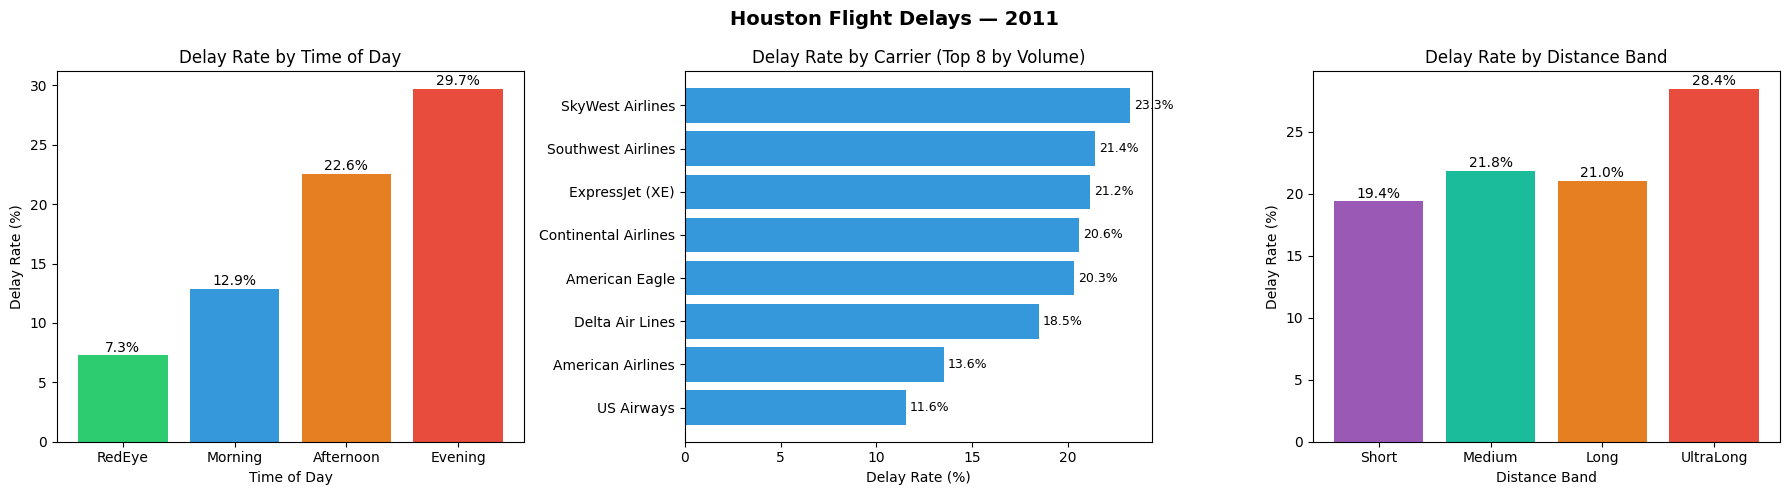

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Houston Flight Delays — 2011', fontsize=14, fontweight='bold')

# PLOT 1: Delay rate by time of day
tod_order = ['RedEye', 'Morning', 'Afternoon', 'Evening']
tod_delay = df.groupby('TimeOfDay')['Delayed'].mean() * 100
tod_delay = tod_delay.reindex(tod_order)

axes[0].bar(tod_delay.index, tod_delay.values, color=['#2ecc71','#3498db','#e67e22','#e74c3c'])
axes[0].set_title('Delay Rate by Time of Day')
axes[0].set_ylabel('Delay Rate (%)')
axes[0].set_xlabel('Time of Day')
for i, v in enumerate(tod_delay.values):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10)

# PLOT 2: Delay rate by carrier (top 8 by flight volume)
top_carriers = df.groupby('CarrierName').size().nlargest(8).index
carrier_data = df[df['CarrierName'].isin(top_carriers)]
carrier_delay2 = carrier_data.groupby('CarrierName')['Delayed'].mean() * 100
carrier_delay2 = carrier_delay2.sort_values(ascending=True)

axes[1].barh(carrier_delay2.index, carrier_delay2.values, color='#3498db')
axes[1].set_title('Delay Rate by Carrier (Top 8 by Volume)')
axes[1].set_xlabel('Delay Rate (%)')
for i, v in enumerate(carrier_delay2.values):
    axes[1].text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=9)

# PLOT 3: Delay rate by distance band
dist_order = ['Short', 'Medium', 'Long', 'UltraLong']
dist_delay = df.groupby('DistanceBand', observed=True)['Delayed'].mean() * 100
dist_delay = dist_delay.reindex(dist_order)

axes[2].bar(dist_delay.index, dist_delay.values, color=['#9b59b6','#1abc9c','#e67e22','#e74c3c'])
axes[2].set_title('Delay Rate by Distance Band')
axes[2].set_ylabel('Delay Rate (%)')
axes[2].set_xlabel('Distance Band')
for i, v in enumerate(dist_delay.values):
    axes[2].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('delay_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## Exploratory Analysis

**Time of day** is the most striking predictor of delay. RedEye departures (before 6am) delay only 7.3% of flights, while Evening departures (after 6pm) delay nearly 1 in 3 at 29.7%. This shows  the delay cascade, disruptions accumulate across the day as each late arrival pushes the next departure back.

**Carrier performance** varies within a band of 11.6% to 23.3%. US Airways and American Airlines are the most reliable out of Houston, while SkyWest and Southwest show the highest delay rates among the top 8 carriers by volume.

**Distance** has a modest effect across short, medium, and long haul routes (19 - 22%), but UltraLong flights spike to 28.4% meaning the greater exposure of transcontinental routes to weather and air traffic control disruptions.

## Model Building — Feature Matrix & Train/Test Split

We encode categorical features using one-hot encoding and split the
dataset into 80% training and 20% testing sets. Only information
available before departure will be used as input,  no leakage from actual
delay or elapsed time columns.

In [ ]:
features = [
    'DayOfWeek',
    'TimeOfDay',
    'UniqueCarrier',    # airline
    'DistanceBand',
    'Origin',           # IAH or HOU
]

In [ ]:
# Build feature matrix
X = pd.get_dummies(df[features], drop_first=False)
y = df['Delayed']

print("=== FEATURE MATRIX SHAPE ===")
print(f"Rows: {X.shape[0]:,}  |  Features: {X.shape[1]}")
print("\n=== FEATURE COLUMNS ===")
print(X.columns.tolist())

=== FEATURE MATRIX SHAPE ===
Rows: 223,874  |  Features: 26

=== FEATURE COLUMNS ===
['DayOfWeek', 'TimeOfDay_Afternoon', 'TimeOfDay_Evening', 'TimeOfDay_Morning', 'TimeOfDay_RedEye', 'UniqueCarrier_AA', 'UniqueCarrier_AS', 'UniqueCarrier_B6', 'UniqueCarrier_CO', 'UniqueCarrier_DL', 'UniqueCarrier_EV', 'UniqueCarrier_F9', 'UniqueCarrier_FL', 'UniqueCarrier_MQ', 'UniqueCarrier_OO', 'UniqueCarrier_UA', 'UniqueCarrier_US', 'UniqueCarrier_WN', 'UniqueCarrier_XE', 'UniqueCarrier_YV', 'DistanceBand_Short', 'DistanceBand_Medium', 'DistanceBand_Long', 'DistanceBand_UltraLong', 'Origin_HOU', 'Origin_IAH']


In [ ]:
#  Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n=== SPLIT ===")
print(f"Training set:  {X_train.shape[0]:,} flights")
print(f"Testing set:   {X_test.shape[0]:,} flights")
print(f"\nDelay rate — train: {y_train.mean()*100:.1f}%")
print(f"Delay rate — test:  {y_test.mean()*100:.1f}%")


=== SPLIT ===
Training set:  179,099 flights
Testing set:   44,775 flights

Delay rate — train: 20.8%
Delay rate — test:  20.8%


26 features, clean split, and the delay rate is identical in both train and test at 20.8%, means it guarantees the split is balanced and no bias was introduced

## Model 1: Logistic Regression (Baseline)

Logistic Regression is our starting point, it is interpretable, fast, and
gives us a performance benchmark that the Random Forest must beat to justify
its added complexity. If Logistic Regression already performs well, we know
the relationship between our features and delay is largely linear.

In [ ]:
# Retrain with class balancing
lr_balanced = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'   # penalizes missing delayed flights more heavily
)
lr_balanced.fit(X_train, y_train)
y_pred_balanced = lr_balanced.predict(X_test)

In [ ]:
print("=== LOGISTIC REGRESSION (BALANCED) ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_balanced)*100:.1f}%")
print(f"Precision: {precision_score(y_test, y_pred_balanced)*100:.1f}%")
print(f"Recall:    {recall_score(y_test, y_pred_balanced)*100:.1f}%")
print(f"F1 Score:  {f1_score(y_test, y_pred_balanced)*100:.1f}%")

=== LOGISTIC REGRESSION (BALANCED) ===
Accuracy:  53.8%
Precision: 26.5%
Recall:    68.8%
F1 Score:  38.3%


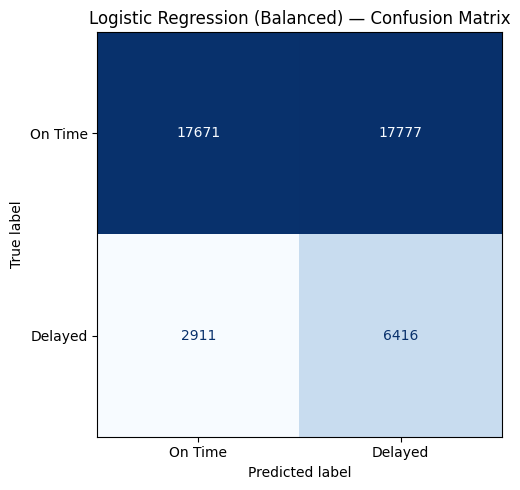

In [ ]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm2 = confusion_matrix(y_test, y_pred_balanced)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2,
                                display_labels=['On Time', 'Delayed'])
disp2.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Logistic Regression (Balanced) — Confusion Matrix')
plt.tight_layout()
plt.savefig('lr_balanced_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

## Model 1 Results — Logistic Regression (Balanced)

The Logistic Regression model achieves an accuracy of 53.8%, a recall of 68.8%, and an F1 score of 38.3%. Out of 9,327 actual delayed flights in the test set, the model correctly identifies 6,416, catching roughly 2 in 3 real delays.

The precision of 26.5% means the model raises more false alarms than correct predictions, flagging 17,777 on-time flights as delayed. This might be an acceptable trade-off in an operational context where missing a real delay is more costly than a false warning.

The F1 of 38.3% is modest, showing the limitation of Logistic
Regression in capturing non-linear interactions between features — e.g, the combined effect of an evening departure on a historically
unreliable carrier. This result sets our baseline. Random Forest needs to exceed F1 of 38.3% to justify its added complexity.

## Model 2 — Random Forest

Random Forest builds hundreds of decision trees, each trained on a random subset of the data and features, then combines their votes to make a final prediction (Breiman, 2001). Unlike Logistic Regression, it captures non-linear relationships — for example, the interaction between Evening departures AND a specific carrier being particularly delay-prone together.

Our baseline Logistic Regression achieved F1 of 38.3%. Random Forest must exceed this to justify its added complexity.

In [ ]:
# Training
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [ ]:
# Metrics
print("=== RANDOM FOREST PERFORMANCE ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf)*100:.1f}%")
print(f"Precision: {precision_score(y_test, y_pred_rf)*100:.1f}%")
print(f"Recall:    {recall_score(y_test, y_pred_rf)*100:.1f}%")
print(f"F1 Score:  {f1_score(y_test, y_pred_rf)*100:.1f}%")

=== RANDOM FOREST PERFORMANCE ===
Accuracy:  59.0%
Precision: 28.2%
Recall:    62.8%
F1 Score:  38.9%


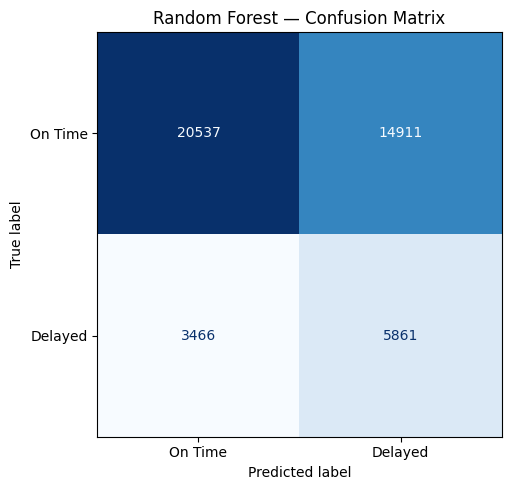

In [ ]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm3 = confusion_matrix(y_test, y_pred_rf)
disp3 = ConfusionMatrixDisplay(confusion_matrix=cm3,
                                display_labels=['On Time', 'Delayed'])
disp3.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.savefig('rf_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Feature importance
print("\n=== FEATURE IMPORTANCE ===")
feat_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)
print(feat_imp.to_string(index=False))


=== FEATURE IMPORTANCE ===
               Feature  Importance
     TimeOfDay_Morning    0.266434
     TimeOfDay_Evening    0.184123
             DayOfWeek    0.170227
   TimeOfDay_Afternoon    0.080981
      UniqueCarrier_WN    0.028385
      TimeOfDay_RedEye    0.026435
    DistanceBand_Short    0.026219
   DistanceBand_Medium    0.021676
            Origin_IAH    0.019842
      UniqueCarrier_US    0.019558
            Origin_HOU    0.018805
      UniqueCarrier_XE    0.018148
      UniqueCarrier_CO    0.017662
     DistanceBand_Long    0.017257
      UniqueCarrier_OO    0.014673
      UniqueCarrier_EV    0.012339
      UniqueCarrier_MQ    0.010503
      UniqueCarrier_AA    0.009971
      UniqueCarrier_UA    0.009701
      UniqueCarrier_FL    0.007897
DistanceBand_UltraLong    0.007461
      UniqueCarrier_DL    0.005236
      UniqueCarrier_B6    0.003337
      UniqueCarrier_F9    0.001336
      UniqueCarrier_AS    0.001007
      UniqueCarrier_YV    0.000788


## Model Comparison — Logistic Regression vs Random Forest

We trained both models on the same feature matrix and evaluated on the same held-out test set of 44,775 flights.

| Metric | Logistic Regression | Random Forest |
|--------|-------------------|---------------|
| Accuracy | 53.8% | 59.0% |
| Precision | 26.5% | 28.2% |
| Recall | 68.8% | 62.8% |
| F1 Score | 38.3% | 38.9% |

Random Forest does better than Logistic Regression on Accuracy,
Precision, and F1 Score. Logistic Regression leads on Recall catching more actual delays, but at the cost of significantly more
false alarms.

The F1 improvement is modest at 0.6 percentage points, showing that
our current feature set (time of day, carrier, distance, and day of
week) captures only part of the signal driving flight delays. We can conclude that when you fly matters more than who operates the flight.

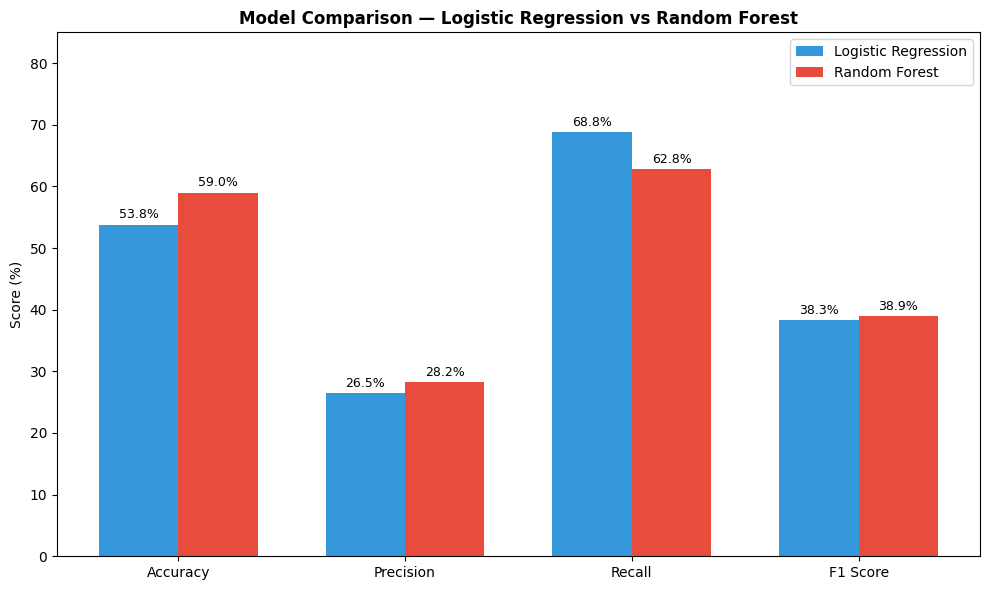

In [ ]:
# Model comparison chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
lr_scores = [53.8, 26.5, 68.8, 38.3]
rf_scores = [59.0, 28.2, 62.8, 38.9]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, lr_scores, width, label='Logistic Regression', color='#3498db')
bars2 = ax.bar(x + width/2, rf_scores, width, label='Random Forest', color='#e74c3c')

ax.set_title('Model Comparison — Logistic Regression vs Random Forest', fontweight='bold')
ax.set_ylabel('Score (%)')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 85)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height()}%', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height()}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()



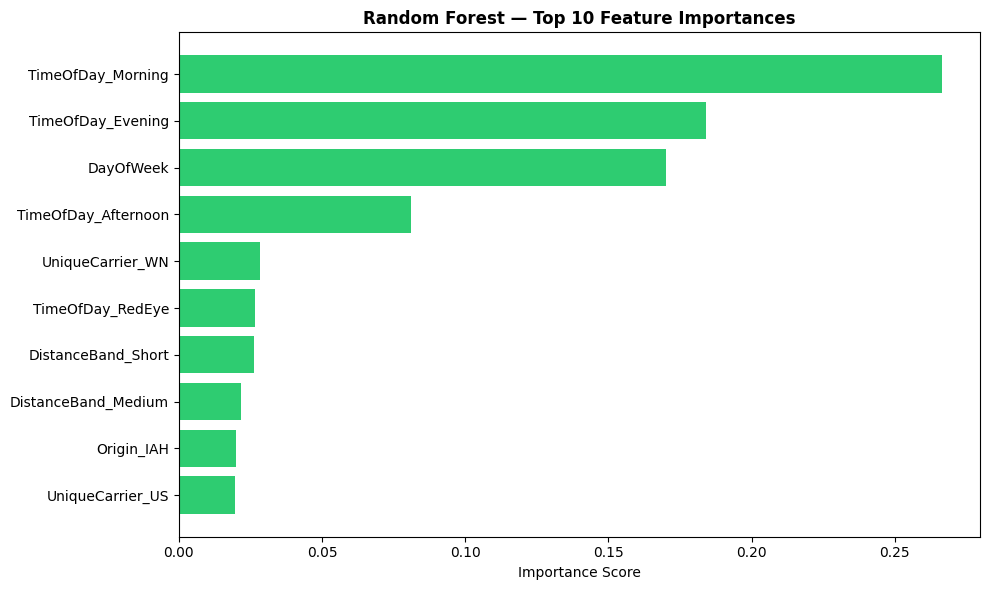

In [ ]:
# Feature importance chart
top_features = feat_imp.head(10)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_features['Feature'][::-1], top_features['Importance'][::-1], color='#2ecc71')
ax.set_title('Random Forest — Top 10 Feature Importances', fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


# Data Dictionary — hflights Dataset

**[Data Source](https://www.kaggle.com/datasets/arunjangir245/airline-flight-dataset-schedule-performance-etc):** hflights (Houston Intercontinental, 2011)

| Column | Description |
|---|---|
| Year | Year the flight operated |
| Month | Month (1–12) |
| DayofMonth | Day of the month |
| DayOfWeek | Day of the week (1=Mon, 7=Sun) |
| DepTime | Scheduled departure time in HHMM format |
| ArrTime | Scheduled arrival time in HHMM format |
| UniqueCarrier | Airline IATA code |
| FlightNum | Flight number |
| TailNum | Unique physical aircraft identifier |
| ActualElapsedTime | Total flight duration in minutes |
| AirTime | Airborne time in minutes (excludes taxi) |
| ArrDelay | Arrival delay in minutes |
| DepDelay | Departure delay in minutes |
| Origin | Departure airport IATA code |
| Dest | Arrival airport IATA code |
| Distance | Flight distance in miles |
| TaxiIn | Minutes from landing to gate arrival |
| TaxiOut | Minutes from gate departure to takeoff |
| Cancelled | 1 = cancelled, 0 = operated |
| CancellationCode | Reason for cancellation (A/B/C/D) |
| Diverted | 1 = diverted, 0 = operated as planned |




## Airport Reference

### Origin Airports (Houston Hubs)
| Code | Full Name |
|---|---|
| HOU | William P. Hobby Airport — Houston, Texas |
| IAH | George Bush Intercontinental Airport — Houston, Texas |

### Destination Airports
| Code | Full Name |
|---|---|
| ABQ | Albuquerque International Sunport — Albuquerque, New Mexico |
| AEX | Alexandria International Airport — Alexandria, Louisiana |
| AMA | Rick Husband Amarillo International — Amarillo, Texas |
| ASE | Aspen/Pitkin County Airport — Aspen, Colorado |
| ATL | Hartsfield-Jackson Atlanta International — Atlanta, Georgia |
| AUS | Austin-Bergstrom International — Austin, Texas |
| AVL | Asheville Regional Airport — Asheville, North Carolina |
| BHM | Birmingham-Shuttlesworth International — Birmingham, Alabama |
| BNA | Nashville International Airport — Nashville, Tennessee |
| BOS | Logan International Airport — Boston, Massachusetts |
| BRO | Brownsville/South Padre Island International — Brownsville, Texas |
| BTR | Baton Rouge Metropolitan Airport — Baton Rouge, Louisiana |
| BWI | Baltimore/Washington International — Baltimore, Maryland |
| CAE | Columbia Metropolitan Airport — Columbia, South Carolina |
| CHS | Charleston International Airport — Charleston, South Carolina |
| CLE | Cleveland Hopkins International — Cleveland, Ohio |
| CLT | Charlotte Douglas International — Charlotte, North Carolina |
| CMH | John Glenn Columbus International — Columbus, Ohio |
| COS | Colorado Springs Airport — Colorado Springs, Colorado |
| CRP | Corpus Christi International — Corpus Christi, Texas |
| CRW | Yeager Airport — Charleston, West Virginia |
| CVG | Cincinnati/Northern Kentucky International — Cincinnati, Ohio |
| DAL | Dallas Love Field — Dallas, Texas |
| DAY | Dayton International Airport — Dayton, Ohio |
| DCA | Ronald Reagan Washington National — Washington, D.C. |
| DEN | Denver International Airport — Denver, Colorado |
| DFW | Dallas/Fort Worth International — Dallas, Texas |
| DSM | Des Moines International Airport — Des Moines, Iowa |
| DTW | Detroit Metropolitan Wayne County — Detroit, Michigan |
| ECP | Northwest Florida Beaches International — Panama City, Florida |
| EGE | Eagle County Regional Airport — Eagle, Colorado |
| ELP | El Paso International Airport — El Paso, Texas |
| EWR | Newark Liberty International — Newark, New Jersey |
| FLL | Fort Lauderdale-Hollywood International — Fort Lauderdale, Florida |
| GPT | Gulfport-Biloxi International — Gulfport, Mississippi |
| GRK | Killeen-Fort Hood Regional Airport — Killeen, Texas |
| GRR | Gerald R. Ford International — Grand Rapids, Michigan |
| GSO | Piedmont Triad International — Greensboro, North Carolina |
| GSP | Greenville-Spartanburg International — Greenville, South Carolina |
| GUC | Gunnison-Crested Butte Regional — Gunnison, Colorado |
| HDN | Yampa Valley Airport — Hayden, Colorado |
| HNL | Daniel K. Inouye International — Honolulu, Hawaii |
| HRL | Valley International Airport — Harlingen, Texas |
| HSV | Huntsville International Airport — Huntsville, Alabama |
| IAD | Washington Dulles International — Washington, D.C. |
| ICT | Wichita Dwight D. Eisenhower National — Wichita, Kansas |
| IND | Indianapolis International Airport — Indianapolis, Indiana |
| JAN | Jackson-Medgar Wiley Evers International — Jackson, Mississippi |
| JAX | Jacksonville International Airport — Jacksonville, Florida |
| JFK | John F. Kennedy International — New York, New York |
| LAS | Harry Reid International Airport — Las Vegas, Nevada |
| LAX | Los Angeles International Airport — Los Angeles, California |
| LBB | Lubbock Preston Smith International — Lubbock, Texas |
| LCH | Lake Charles Regional Airport — Lake Charles, Louisiana |
| LEX | Blue Grass Airport — Lexington, Kentucky |
| LFT | Lafayette Regional Airport — Lafayette, Louisiana |
| LGA | LaGuardia Airport — New York, New York |
| LIT | Bill and Hillary Clinton National — Little Rock, Arkansas |
| LRD | Laredo International Airport — Laredo, Texas |
| MAF | Midland International Air & Space Port — Midland, Texas |
| MCI | Kansas City International Airport — Kansas City, Missouri |
| MCO | Orlando International Airport — Orlando, Florida |
| MDW | Chicago Midway International — Chicago, Illinois |
| MEM | Memphis International Airport — Memphis, Tennessee |
| MFE | McAllen Miller International — McAllen, Texas |
| MIA | Miami International Airport — Miami, Florida |
| MKE | Milwaukee Mitchell International — Milwaukee, Wisconsin |
| MOB | Mobile Regional Airport — Mobile, Alabama |
| MSP | Minneapolis-Saint Paul International — Minneapolis, Minnesota |
| MSY | Louis Armstrong New Orleans International — New Orleans, Louisiana |
| MTJ | Montrose Regional Airport — Montrose, Colorado |
| OAK | Oakland International Airport — Oakland, California |
| OKC | Will Rogers World Airport — Oklahoma City, Oklahoma |
| OMA | Eppley Airfield — Omaha, Nebraska |
| ONT | Ontario International Airport — Ontario, California |
| ORD | O'Hare International Airport — Chicago, Illinois |
| ORF | Norfolk International Airport — Norfolk, Virginia |
| PBI | Palm Beach International Airport — West Palm Beach, Florida |
| PDX | Portland International Airport — Portland, Oregon |
| PHL | Philadelphia International Airport — Philadelphia, Pennsylvania |
| PHX | Phoenix Sky Harbor International — Phoenix, Arizona |
| PIT | Pittsburgh International Airport — Pittsburgh, Pennsylvania |
| PNS | Pensacola International Airport — Pensacola, Florida |
| RDU | Raleigh-Durham International — Raleigh, North Carolina |
| RIC | Richmond International Airport — Richmond, Virginia |
| RSW | Southwest Florida International — Fort Myers, Florida |
| SAN | San Diego International Airport — San Diego, California |
| SAT | San Antonio International Airport — San Antonio, Texas |
| SAV | Savannah/Hilton Head International — Savannah, Georgia |
| SDF | Louisville Muhammad Ali International — Louisville, Kentucky |
| SEA | Seattle-Tacoma International — Seattle, Washington |
| SFO | San Francisco International Airport — San Francisco, California |
| SHV | Shreveport Regional Airport — Shreveport, Louisiana |
| SJC | Norman Y. Mineta San Jose International — San Jose, California |
| SJU | Luis Muñoz Marín International — San Juan, Puerto Rico |
| SLC | Salt Lake City International Airport — Salt Lake City, Utah |
| SMF | Sacramento International Airport — Sacramento, California |
| SNA | John Wayne Airport — Santa Ana, California |
| STL | St. Louis Lambert International — St. Louis, Missouri |
| TPA | Tampa International Airport — Tampa, Florida |
| TUL | Tulsa International Airport — Tulsa, Oklahoma |
| TUS | Tucson International Airport — Tucson, Arizona |
| TYS | McGhee Tyson Airport — Knoxville, Tennessee |
| VPS | Destin-Fort Walton Beach Airport — Valparaiso, Florida |
| XNA | Northwest Arkansas National Airport — Bentonville, Arkansas |